# Visualize the Education's Impact

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/mnt/d/OneDrive/MLD01_Article'

## Impact Package

In [4]:
import math
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import pandas as pd

from glob import glob
from matplotlib import cm

In [5]:
import LoadDataFromDisk

## Function

In [6]:
def read_all_probs_df_from_parquet(results_addr:str) -> dict:
    """
    Read all .parquet files in a directory into a dictionary of DataFrames.

    This function scans the specified directory for all .parquet files, reads each file into a pandas DataFrame,
    and stores them in a dictionary with keys based on the file names (without the .parquet extension).

    Args:
        results_addr (str): The directory path containing .parquet files.

    Returns:
        dict: A dictionary where keys are file names (without extension) and values are pandas DataFrames.
    """
    probs_dictionary = {}
    file_address = sorted(glob(os.path.join(results_addr, '*.parquet')))
    for file in file_address:
        key = os.path.basename(file).replace('.parquet', '')
        probs_dictionary[key] = pd.read_parquet(file)
    return probs_dictionary

In [67]:
def visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary: dict, 
    input_name_list: list,
    df_stratification: pd.DataFrame,
    group_name : list,
    labels: list = None,
    save_address: str = "violin_stratification.jpg"
) -> None:
    """
    Visualize violin plots for factual and counterfactual probabilities across stratification groups.

    Args:
        probs_dictionary (dict): A dictionary containing probability arrays (with keys like 'mean').
        input_name_list (list): A list of factual input names to visualize.
        df_stratification (pd.DataFrame): Stratification variable (e.g., gender, age group, province).
        labels (list): Optional custom labels for x-axis (otherwise auto-generated).
        save_address (str): Path to save the output figure (default: 'violin_stratification.jpg').
    """

    n_plots = len(input_name_list)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

    titles = [
        "(a) Heard about Climate Change Dummy", "(b) Climate Change Awareness Dummy",
        "(c) Soil and Water Conservation Measures in Past Dummy", "(d) Risk Reduction Measurement in Past Dummy",
        "(e) Road Improvement in Past Dummy", "(f) Community Participation in Past Dummy"
        
    ]

    for idx, input_name in enumerate(input_name_list):
        ax = axes[idx]

        # Extract factual & counterfactual means
        factual = probs_dictionary.get(f'{input_name}')['mean']
        counterfactual = probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
        strat_var = df_stratification.iloc[:, 0]

        # Unique groups
        groups = sorted(strat_var.unique())

        # Build data dynamically (handles any number of groups)
        data = []
        x_labels = []
        for g in groups:
            for fc_label, arr in zip(['Factual', 'Counterfactual'], [factual, counterfactual]):
                data.append(arr[strat_var == g])
                x_labels.append(f"{fc_label} - {g}")

        # Violin plot
        parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
        cmap_positions = np.linspace(0.15, 0.85, len(data))
        colors = [cm.viridis(c) for c in cmap_positions]
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)

        # Line colors
        for key, color in {'cmeans': 'orange', 'cmedians': 'red', 'cbars': 'black',
                           'cmaxes': 'blue', 'cmins': 'blue'}.items():
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.8 if key == 'cbars' else 2)

        # Statistics
        means = [np.mean(d) for d in data]
        medians = [np.median(d) for d in data]
        mins = [np.min(d) for d in data]
        maxes = [np.max(d) for d in data]
        positions = np.arange(1, len(data) + 1)

        # Annotate (with white edges)
        for pos, mean, median, minv, maxv in zip(positions, means, medians, mins, maxes):
            texts = [
                ax.text(pos - 0.04, mean, f"Mean: {mean*100:.2f}%", fontsize=7, va='bottom', ha='center', color='black'),
                ax.text(pos - 0.04, median, f"Median: {median*100:.2f}%", fontsize=7, va='top', ha='center', color='black'),
                ax.text(pos - 0.04, maxv, f"Max: {maxv*100:.2f}%", fontsize=7, va='bottom', ha='center', color='black'),
                ax.text(pos - 0.04, minv, f"Min: {minv*100:.2f}%", fontsize=7, va='top', ha='center', color='black')
            ]
            for t in texts:
                t.set_path_effects([
                    path_effects.Stroke(linewidth=2.5, foreground='white'),
                    path_effects.Normal()
                ])

        ax.text(
            1.5, 0.8, f"{group_name[0]}:\n{(means[1] - means[0])*100:.2f}%",
            fontsize=8, va='top', ha='center', color='black'
        )
        ax.text(
            3.5, 0.8, f"{group_name[1]}:\n{(means[3] - means[2])*100:.2f}%",
            fontsize=8, va='top', ha='center', color='black'
        )
        # Subplot label (e.g. a, b, c…)
        ax.set_title(titles[idx], fontsize=10, loc = 'left')

        # Axis setup (no titles)
        ax.set_xticks(np.arange(1, len(data) + 1))
        ax.set_xticklabels(labels if labels else x_labels, rotation=15, fontsize=8)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=8)
        ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove unused subplots
    for ax in axes[n_plots:]:
        ax.axis('off')

    # Layout and save (no figure title)
    plt.tight_layout()
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

In [58]:
def visualize_factual_counterfactual_violin_plots_total_direct_indirect(
    probs_dictionary: dict, 
    direct_probs_dictionary: dict, 
    indirect_probs_dictionary: dict, 
    input_name_list: list,
    save_address: str
) -> None:
    """
    Visualize violin plots for factual and counterfactual probabilities in a grid.

    Args:
        probs_dictionary (dict): A dictionary containing probability arrays (with keys like 'mean').
        input_name_list (list): A list of factual input names to visualize.
        save_address (str): Path to save the output figure (e.g. 'results/violin_plots.jpg').
    """
    n_plots = len(input_name_list)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    titles = [
        "(a) Heard about Climate Change Dummy", "(b) Climate Change Awareness Dummy",
        "(c) Soil and Water Conservation Measures in Past Dummy", "(d) Risk Reduction Measurement in Past Dummy",
        "(e) Road Improvement in Past Dummy", "(f) Community Participation in Past Dummy"
        
    ]

    for idx, input_name in enumerate(input_name_list):
        ax = axes[idx]

        # Extract factual & counterfactual means
        factual = probs_dictionary.get(f'{input_name}')['mean']
        counterfactual = probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
        if idx == 0:
            # Knowledge is the first analytical layer and has no upstream indirect pathway.
            data = [factual, counterfactual]
            labels = ['Factual for\nTotal Effect', 'Counterfactual for\nTotal Effect']
        else:
            d_factual = direct_probs_dictionary.get(f'{input_name}')['mean']
            d_counterfactual = direct_probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
            ind_factual = indirect_probs_dictionary.get(f'{input_name}')['mean']
            ind_counterfactual = indirect_probs_dictionary.get(f'counterfactual_{input_name.split("factual_")[1]}')['mean']
            data = [factual, counterfactual, d_factual, d_counterfactual, ind_factual, ind_counterfactual]
            labels = ['Factual for\nTotal Effect', 'Counterfactual for\nTotal Effect',
                      'Factual for\nDirect Effect', 'Counterfactual for\nDirect Effect',
                      'Factual for\nIndirect Effect', 'Counterfactual for\nIndirect Effect']

        # Violin plot
        parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True)
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c",
                  "#d62728", "#9467bd", "#8c564b"]
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)

        # Line colors
        for key, color in {'cmeans': 'orange', 'cmedians': 'red', 'cbars': 'black', 'cmaxes': 'blue', 'cmins': 'blue'}.items():
            if key in parts:
                parts[key].set_color(color)
                parts[key].set_linewidth(1.8 if key in ['cbars'] else 2)

        # Statistics
        means = [np.mean(d) for d in data]
        medians = [np.median(d) for d in data]
        mins = [np.min(d) for d in data]
        maxes = [np.max(d) for d in data]
        positions = np.arange(1, len(data) + 1)

        # Annotate
        for pos, mean, median, minv, maxv in zip(positions, means, medians, mins, maxes):
            texts = [
                ax.text(pos, mean, f"Mean: {mean*100:.2f}%", fontsize=7, va='bottom', ha='center', color='black'),
                ax.text(pos, median, f"Median: {median*100:.2f}%", fontsize=7, va='top', ha='center', color='black'),
                ax.text(pos, maxv, f"Max: {maxv*100:.2f}%", fontsize=7, va='bottom', ha='center', color='black'),
                ax.text(pos, minv, f"Min: {minv*100:.2f}%", fontsize=7, va='top', ha='center', color='black')
            ]
            for t in texts:
                t.set_path_effects([
                    path_effects.Stroke(linewidth=2.5, foreground='white'),
                    path_effects.Normal()
                ])

        ax.text(
            1.5, 0.8, f"Total\nEffect:\n{(means[1] - means[0])*100:.2f}%",
            fontsize=7, va='top', ha='center', color='black'
        )
        if idx > 0:
            ax.text(
                3.5, 0.8, f"Direct\nEffect:\n{(means[3] - means[2])*100:.2f}%",
                fontsize=7, va='top', ha='center', color='black'
            )
            ax.text(
                5.5, 0.8, f"Indirect\nEffect:\n{(means[5] - means[4])*100:.2f}%",
                fontsize=7, va='top', ha='center', color='black'
            )
        
        # Subplot title (e.g. a, b, c…)
        ax.set_title(titles[idx], fontsize=10, loc = 'left')

        # Axes formatting
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation = 30, fontsize=8)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=8)
        ax.set_ylabel('Probability')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove unused subplots
    for ax in axes[n_plots:]:
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Save figure (300 dpi JPEG)
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

## Run

In [9]:
if __name__ == '__main__':
    pass

In [10]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results', exist_ok=True)

In [11]:
probs_dictionary = read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [12]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

In [13]:
len(probs_dictionary.keys())

12

In [18]:
os.makedirs(MLD01e1_RESULTS_DIRECT_ADDR := './MLD01e_Results/MLD01e1_Results/direct', exist_ok=True)

In [19]:
direct_probs_dictionary = read_all_probs_df_from_parquet(MLD01e1_RESULTS_DIRECT_ADDR)

In [20]:
os.makedirs(MLD01e1_RESULTS_INDIRECT_ADDR := './MLD01e_Results/MLD01e1_Results/indirect', exist_ok=True)

In [21]:
indirect_probs_dictionary = read_all_probs_df_from_parquet(MLD01e1_RESULTS_INDIRECT_ADDR)

### Total Effect

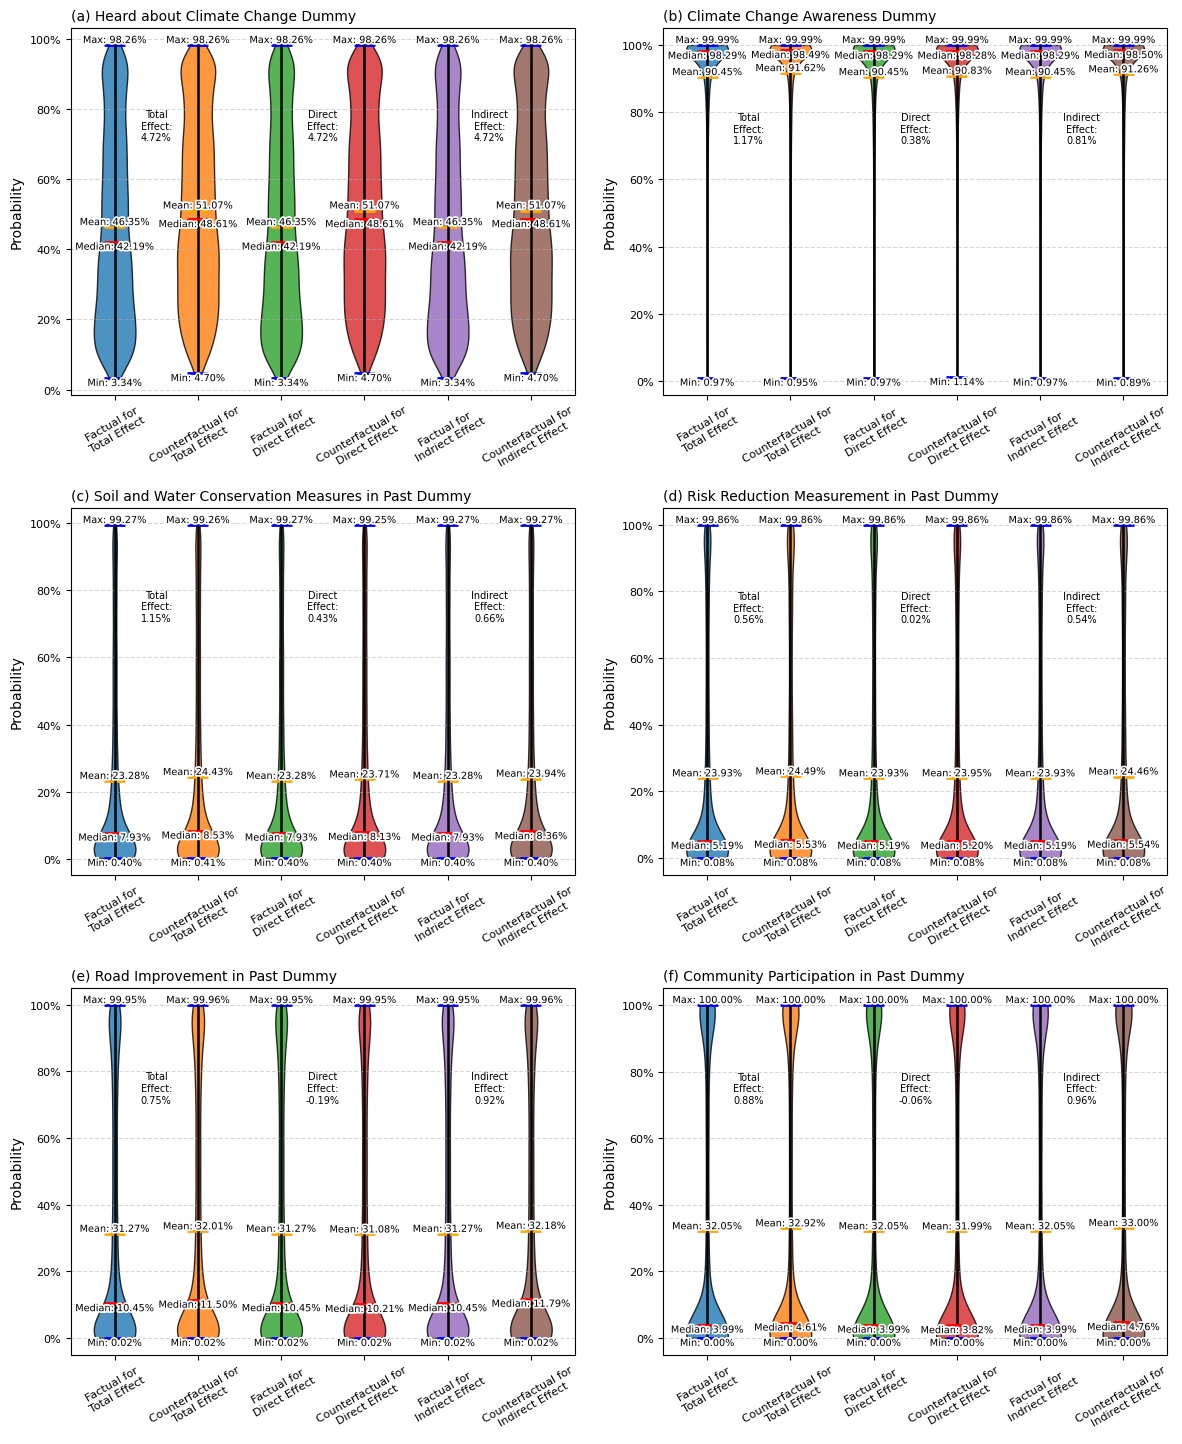

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_plots_6lines.jpg


In [52]:
visualize_factual_counterfactual_violin_plots_total_direct_indirect(
    probs_dictionary=probs_dictionary,
    direct_probs_dictionary = direct_probs_dictionary,
    indirect_probs_dictionary = indirect_probs_dictionary,
    input_name_list=input_name_list,
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_plots_6lines.jpg'
    )

### Visualize Gender effect

In [54]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Female']].reset_index(drop=True)

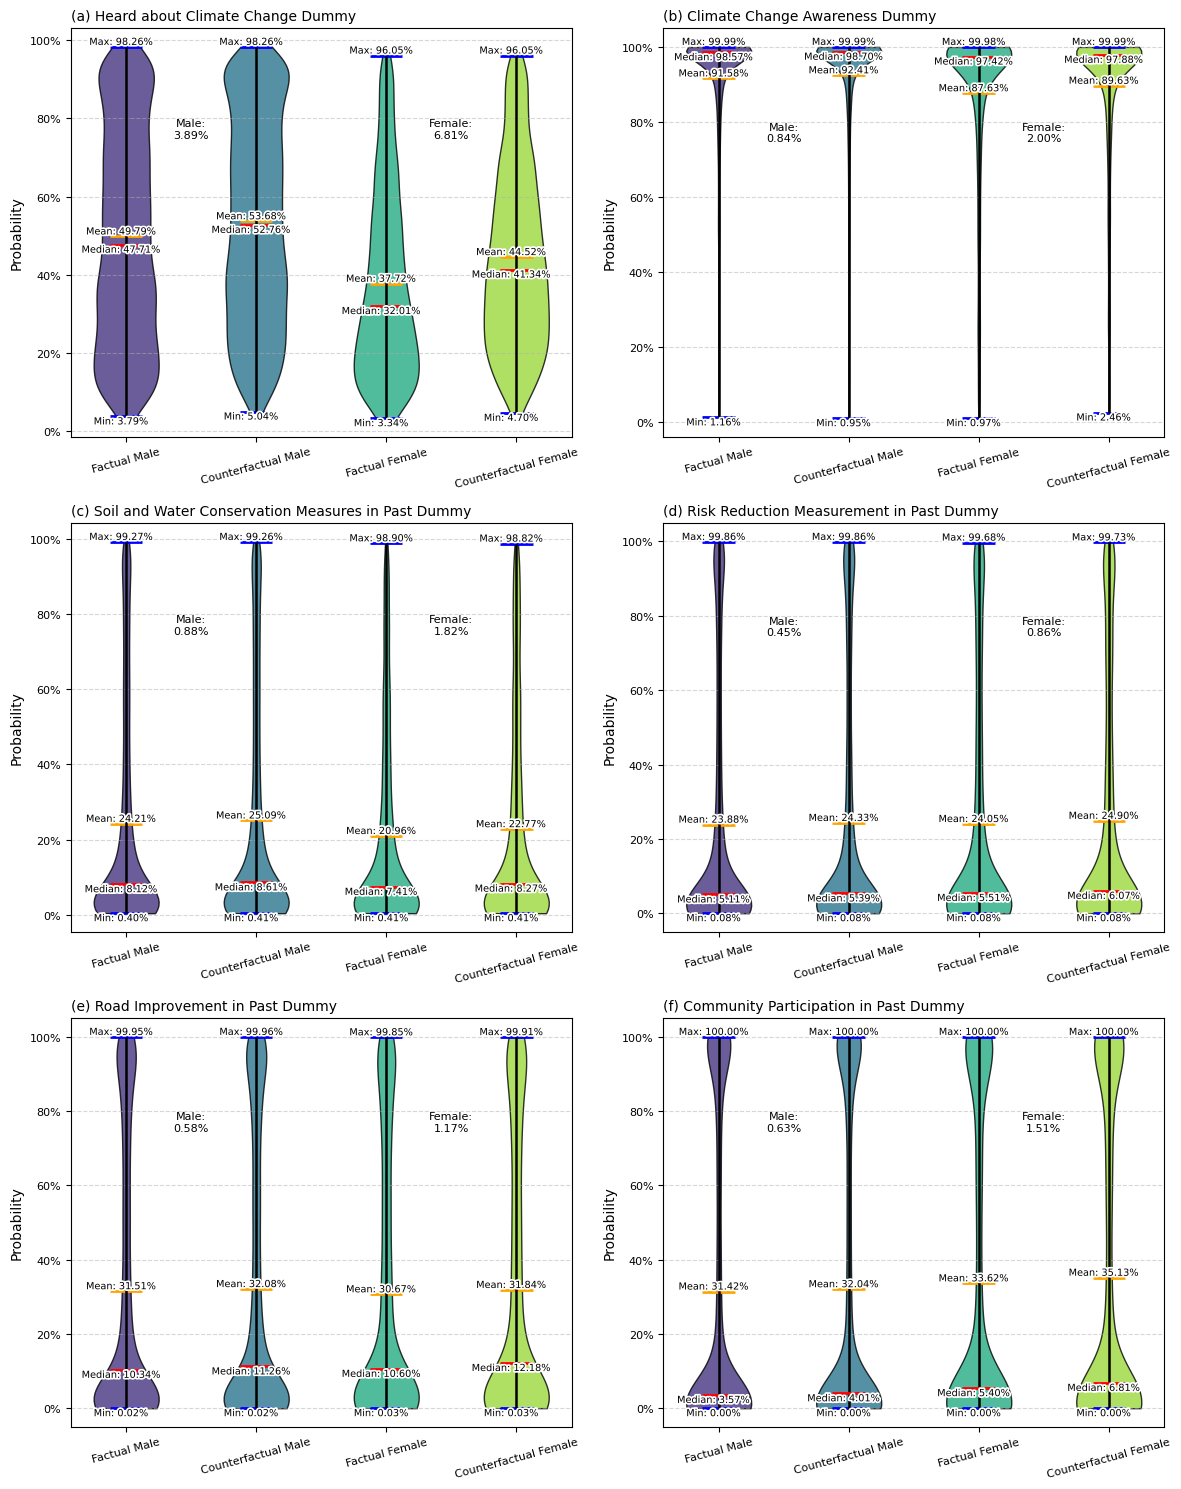

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_gender.jpg


In [69]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    group_name = ['Male', 'Female'],
    labels=['Factual Male', 'Counterfactual Male', 'Factual Female', 'Counterfactual Female'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_gender.jpg'
    )

### Visualize Senior

In [70]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [71]:
print(df_all.columns[:40])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')


In [72]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Age']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['Above65_Dummy'] = (df_stratification['Respon_Age'] > 65).astype(int)
df_stratification = df_stratification[['Above65_Dummy']]

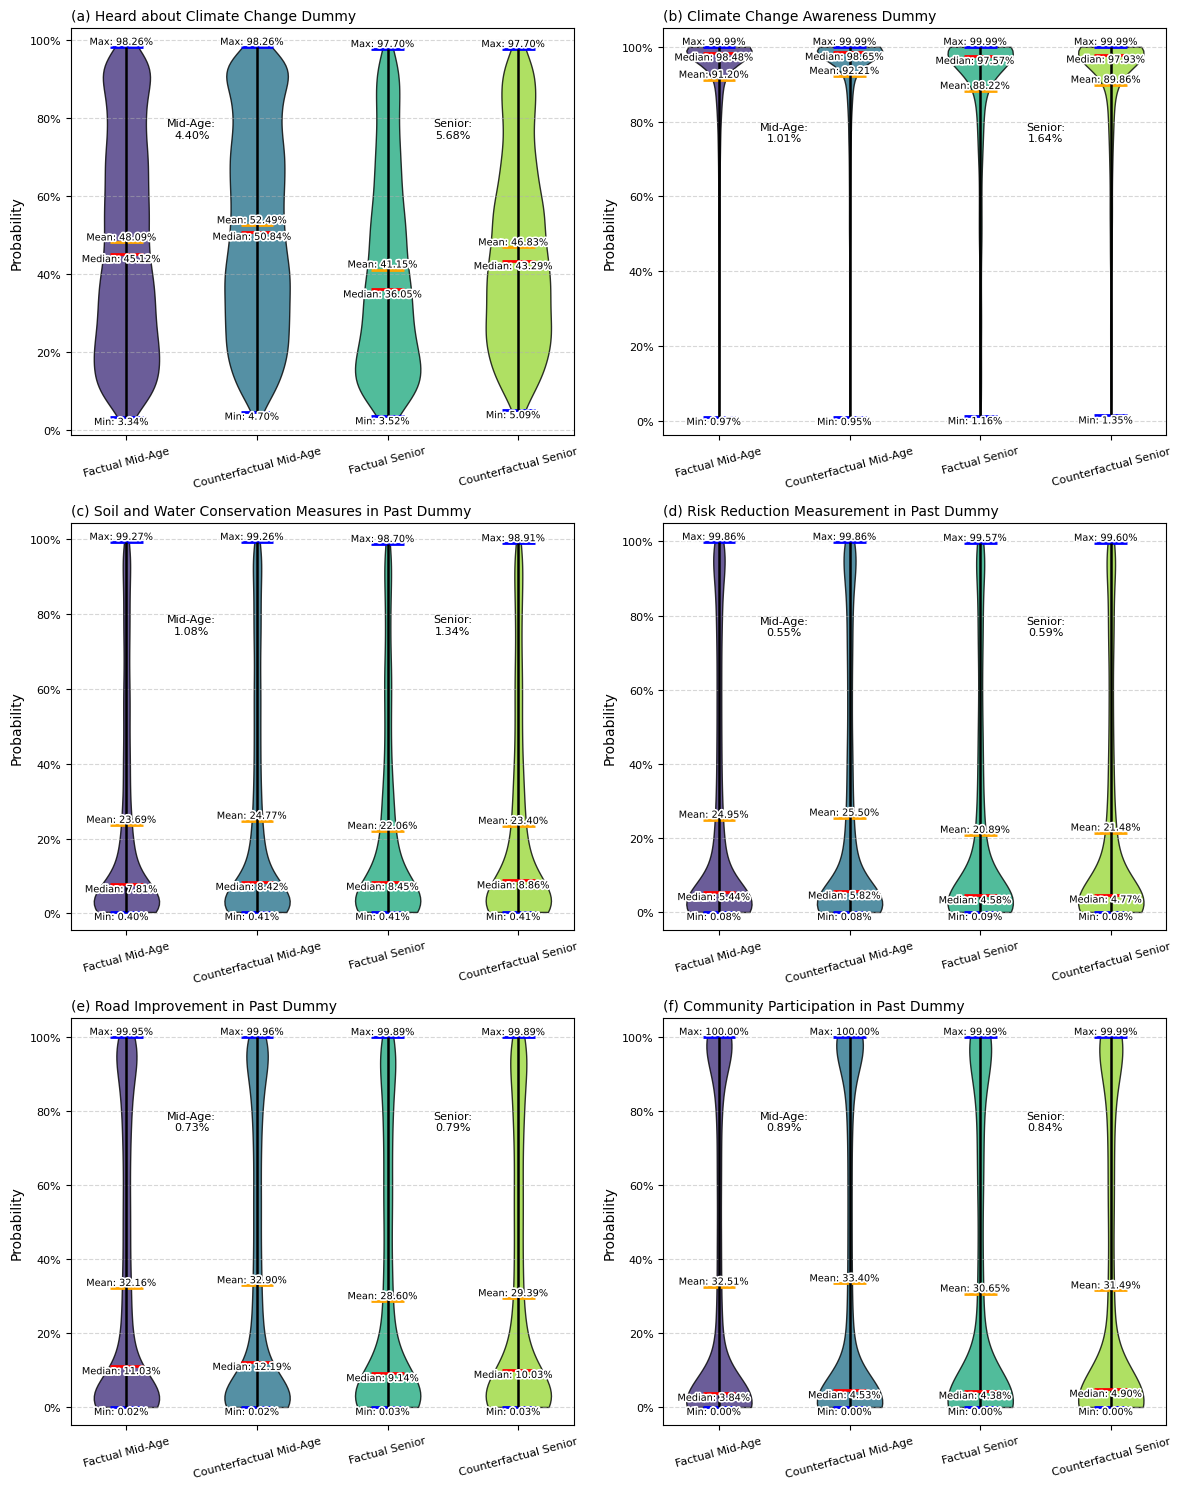

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg


In [73]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    group_name = ['Mid-Age', 'Senior'],
    labels=['Factual Mid-Age', 'Counterfactual Mid-Age', 'Factual Senior', 'Counterfactual Senior'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg'
    )

### Visualize Rural effect

In [130]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Rural_Dummy']].reset_index(drop=True)

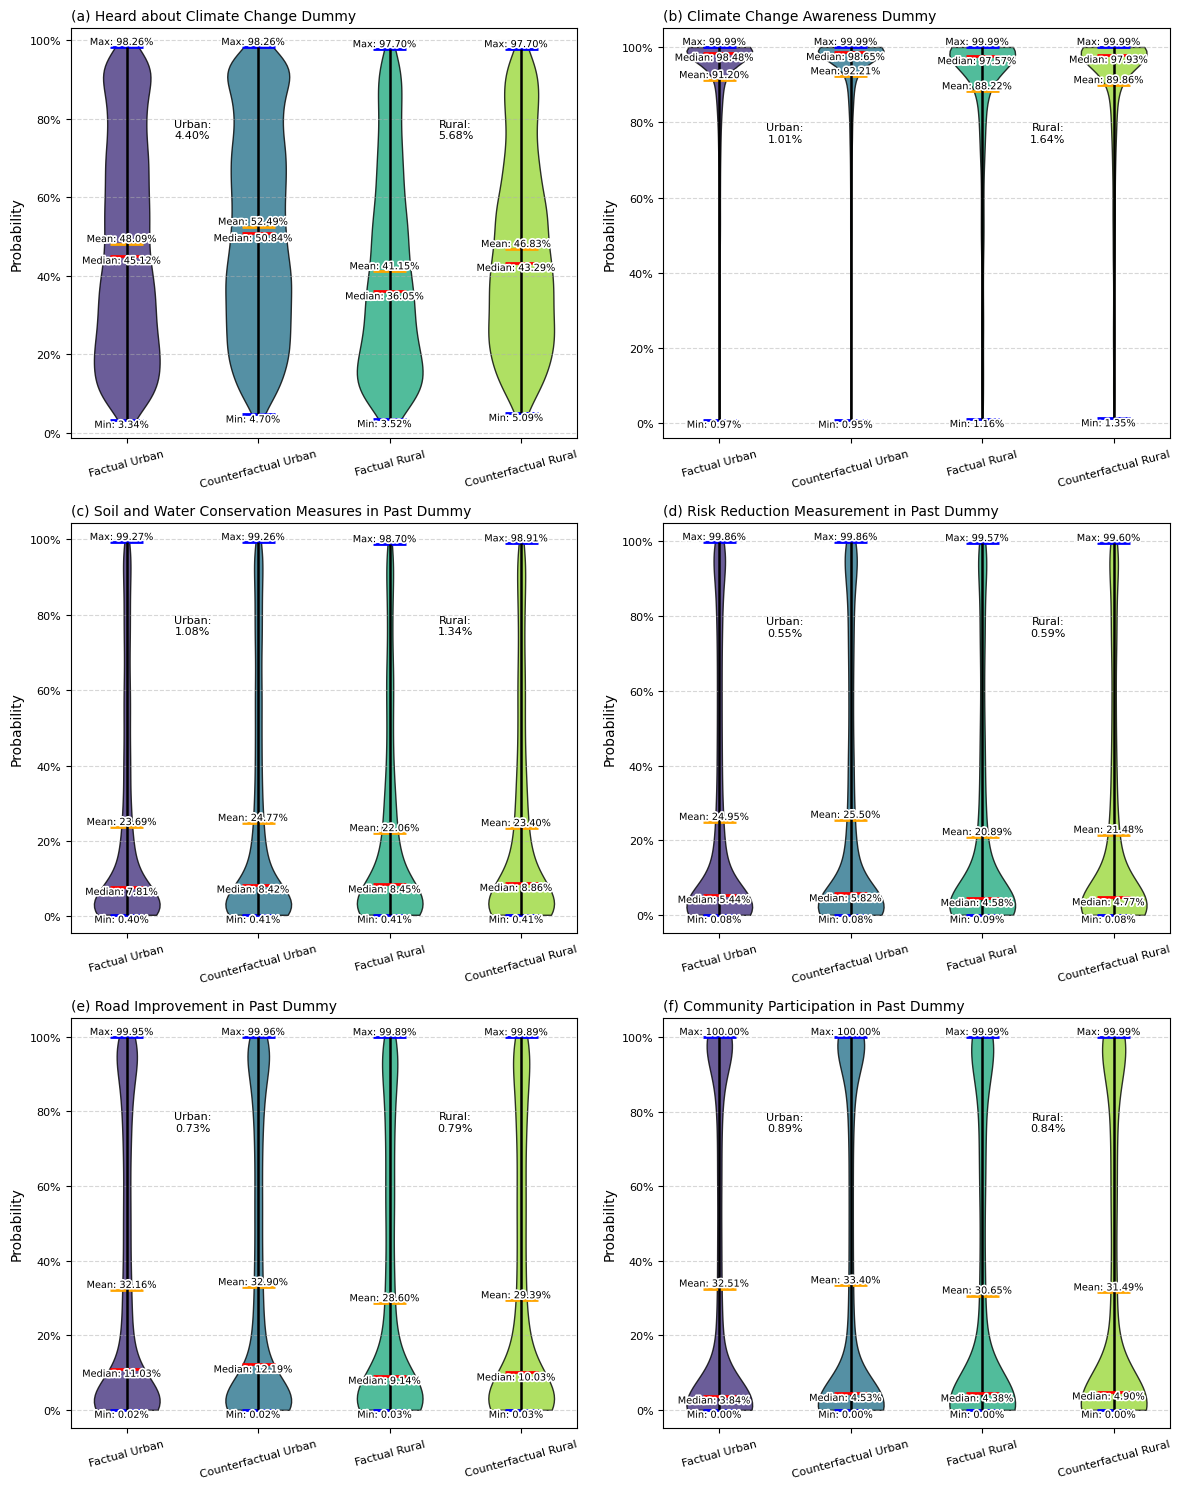

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg


In [74]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    group_name = ['Urban', 'Rural'],
    labels=['Factual Urban', 'Counterfactual Urban', 'Factual Rural',  'Counterfactual Rural'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg'
    )

### Visualize Total Income

In [75]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [76]:
df_all['TotalIncome'].describe()

count    1.156800e+04
mean     3.239423e+05
std      1.143592e+06
min      0.000000e+00
25%      5.400000e+04
50%      1.700000e+05
75%      4.000000e+05
max      9.920000e+07
Name: TotalIncome, dtype: float64

In [77]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['TotalIncome']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['HighIncome_Dummy'] = (df_stratification['TotalIncome'] > 1.700000e+05).astype(int)
df_stratification = df_stratification[['HighIncome_Dummy']]

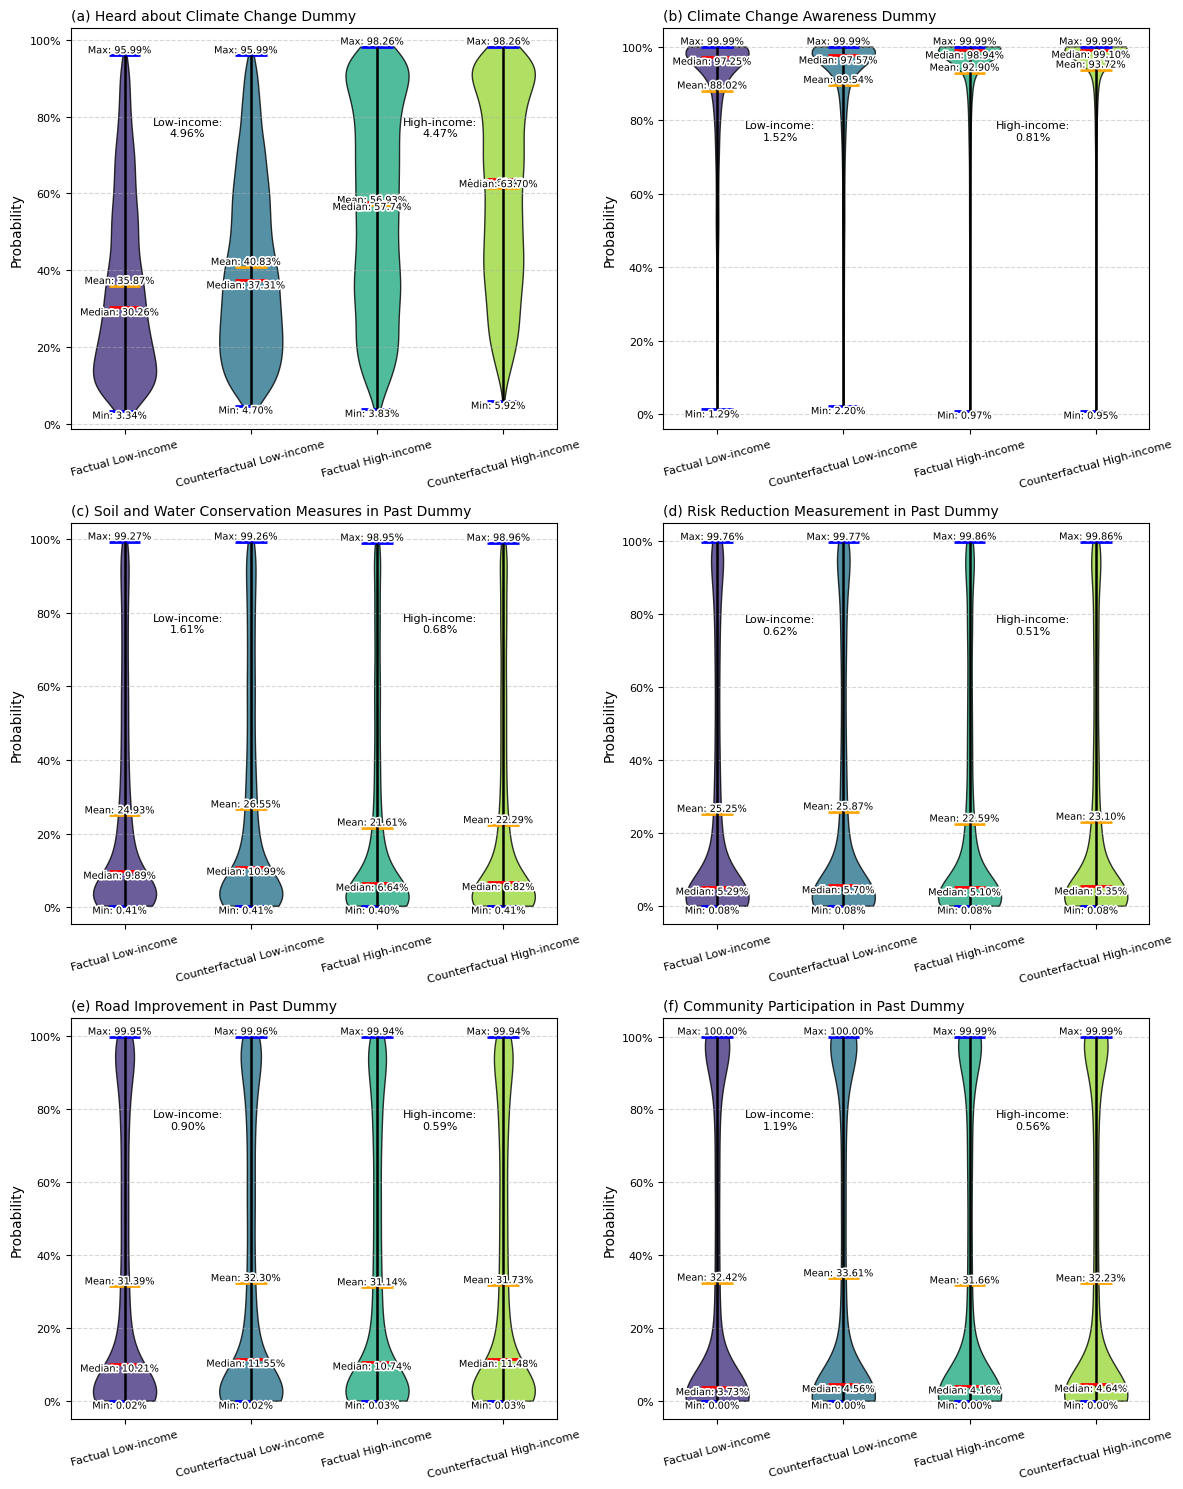

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg


In [80]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    group_name = ['Low-income', 'High-income'],
    labels=['Factual Low-income', 'Counterfactual Low-income',  'Factual High-income', 'Counterfactual High-income'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg'
    )